# 1D Riemann for Ideal Gas

In [108]:
import jax
import jax.numpy as jnp
import jax.random as jr
import jax.nn as jnn
import matplotlib.pyplot as plt
import optax
from tqdm import tqdm

GAMMA=5./3.
ALPHA = (GAMMA-1.)/(2.*GAMMA)
BETA = (GAMMA-1.)/(GAMMA+1.)
MU = (GAMMA-1.)/2.

In [103]:
@jax.jit
def fjump(p, pK, rhoK):
    AK = 2 / ((GAMMA+1) * rhoK)
    BK = pK * BETA
    cK = jnp.sqrt(GAMMA*pK/rhoK)

    shock = jnp.sqrt(AK/(p+BK)) * (p - pK)
    rarefaction = ((p/pK)**ALPHA - 1) * cK / MU

    return jnp.where(p > pK, shock, rarefaction)

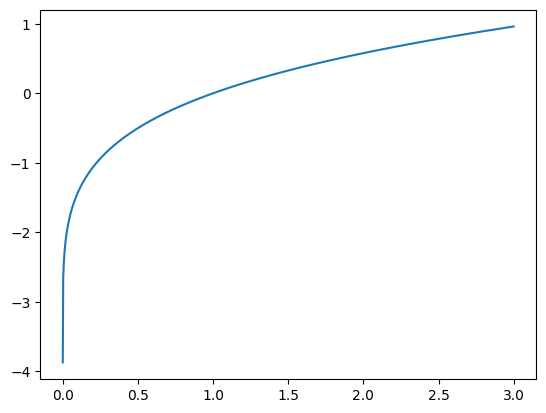

In [104]:
pK = 1
rhoK = 1
plist = jnp.linspace(0, 3, 1000)
flist = jax.vmap(fjump, in_axes=(0, None, None))(plist, pK, rhoK)
plt.plot(plist, flist)

In [64]:
rhoL = 1.0
uL = 0.5
pL = 3.0
rhoR = 0.4
uR = 0.3
pR = 1.0
gas_params = (rhoL, uL, pL, rhoR, uR, pR)

## simple Newton method solver

In [106]:
@jax.jit
def fstar(pstar, gas_state):
    rhoL, pL, rhoR, pR, uRL = gas_state
    return fjump(pstar, pL, rhoL) + fjump(pstar, pR, rhoR) + uRL

dfstar_dp = jax.grad(fstar, argnums=0)

@jax.jit
def find_pstar(gas_state, p0=1.0):
    def cond(state):
        pstar, fstar_, i = state
        return (jnp.abs(fstar_) >= 1e-6) & (i < 100)

    def body(state):
        pstar, _, i = state
        fstar_ = fstar(pstar, gas_state)
        dfstar_ = dfstar_dp(pstar, gas_state)
        pstar = pstar - fstar_ / dfstar_
        return pstar, fstar(pstar, gas_state), i + 1

    init = (p0, fstar(p0, gas_state), 0)
    pstar, fstar_final, _iters = jax.lax.while_loop(cond, body, init)
    return pstar, fstar_final

@jax.jit
def find_pstar_log(gas_state_log, logp0=0.0):
    gas_state = jnp.concatenate([10.**(gas_state_log[:4]), gas_state_log[4:5]]) # uRL is not log
    p0 = 10.**logp0
    pstar, fstar_final = find_pstar(gas_state, p0=p0)
    jax.debug.print("pstar = {}", pstar)
    return jnp.log10(pstar), fstar_final

In [95]:
%%time
rhoL = 1.0
uL = 0.5
pL = 3.0
rhoR = 0.4
uR = 0.3
pR = 1.0
uRL = uR - uL
gas_state = jnp.array([rhoL, pL, rhoR, pR, uRL])
gas_state_log = jnp.concatenate([jnp.log10(gas_state[:4]), gas_state[4:5]]) # dont log uRL

pstar, _ = find_pstar(gas_state)
pstar_log, _ = find_pstar_log(gas_state_log)
print(pstar, 10.**pstar_log)

pstar = 1.8606771230697632
1.8606771 1.8606771
CPU times: user 272 ms, sys: 45 ms, total: 317 ms
Wall time: 193 ms


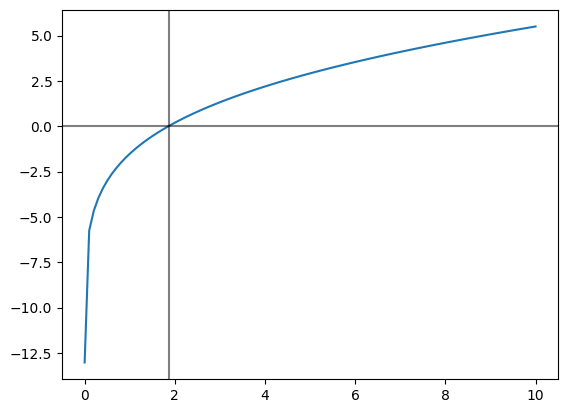

In [96]:
plist = jnp.linspace(0, 10, 100)
flist = fstar(plist, gas_state)
plt.plot(plist, flist)
plt.axvline(pstar, c='k', alpha=0.5)
plt.axhline(0, c='k', alpha=0.5)

# Machine do learn time

In [160]:
def init_mlp(key, layer_sizes):
    params = []
    for i in range(len(layer_sizes)-1):
        key, subkey = jr.split(key)
        scale = jnp.sqrt(2.0/layer_sizes[i])
        w = jr.normal(subkey, (layer_sizes[i], layer_sizes[i+1]))*scale
        b = jnp.zeros(layer_sizes[i+1])
        params.append((w, b))
    return params

def forward(params, gas_state_log):
    x = gas_state_log
    for w, b in params[:-1]:
        x = jnn.silu(x @ w + b)
    w, b = params[-1]
    return (x @ w + b).squeeze()

def loss_fn(params, gas_states_log):
    logpstar_nn = forward(params, gas_states_log)                          # (batch_size,)
    pstar_nn = 10.**logpstar_nn
    gas_states = jnp.concatenate([10.**(gas_states_log[:, :4]), gas_states_log[:, 4:5]], axis=-1)  # (batch_size, 5)

    fstar_nn = jax.vmap(fstar)(pstar_nn, gas_states)                       # (batch_size,)
    resid = jnp.mean(fstar_nn**2)

    return resid

In [ ]:
key = jr.PRNGKey(42)
params = init_mlp(key, [5, 64, 64, 1])

rhoL = 1.0
uL = 0.5
pL = 3.0
rhoR = 0.4
uR = 0.3
pR = 1.0
uRL = uR - uL
gas_state = jnp.array([rhoL, pL, rhoR, pR, uRL])
gas_state_log = jnp.concatenate([jnp.log10(gas_state[:4]), gas_state[4:5]]) # dont log uRL

logpstar_nn = forward(params, jnp.array(gas_state_log))
loss, grads = jax.value_and_grad(loss_fn)(params, gas_state_log.reshape)
print(logpstar_nn, loss, grads[0][0].shape)

optimizer = optax.adam(1e-3)
opt_state = optimizer.init(params)

TypeError: Shapes must be 1D sequences of concrete values of integer type, got (None, -1).

In [181]:
from copy import deepcopy

In [182]:
key = jr.PRNGKey(42)
params = init_mlp(key, [5, 64, 64, 1])

optimizer = optax.adam(1e-3)
opt_state = optimizer.init(params)

@jax.jit
def train_step(params, opt_state, gas_states_log):
    # jax.debug.print("gas_state_log={}, {}, {}, {}, {}", gas_state_log[0], gas_state_log[1], gas_state_log[2], gas_state_log[3], gas_state_log[4])
    loss, grads = jax.value_and_grad(loss_fn)(params, gas_states_log)
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

loss_trace = jnp.zeros(20_000)
batch_size = 256
params_at2500 = None
for epoch in (pbar := tqdm(range(20_000))):
    keys = jr.split(key, 5)
    logrhoL = jr.uniform(keys[0], shape=(batch_size,), minval=-2, maxval=2)
    logpL   = jr.uniform(keys[1], shape=(batch_size,), minval=-2, maxval=2)
    logrhoR = jr.uniform(keys[2], shape=(batch_size,), minval=-2, maxval=2)
    logpR   = jr.uniform(keys[3], shape=(batch_size,), minval=-2, maxval=2)
    uRL     = jr.uniform(keys[4], shape=(batch_size,), minval=-1, maxval=1)
    gas_states_log = jnp.stack([logrhoL, logpL, logrhoR, logpR, uRL], axis=-1)  # (batch_size, 5)

    params, opt_state, loss = train_step(params, opt_state, gas_states_log)
    if epoch==2500:
        params_at2500 = deepcopy(params)
    loss_trace = loss_trace.at[epoch].set(loss)
    if epoch % 2000 == 0:
        pbar.set_postfix(loss=f"{loss:.2e}")

100%|██████████| 20000/20000 [00:15<00:00, 1301.11it/s, loss=3.86e-03]


In [178]:
loss_trace

Array([1.4599641e+03, 1.0660140e+03, 8.6726318e+02, ..., 1.2366763e-01,
       1.8250208e-01, 2.7667987e-01], dtype=float32)

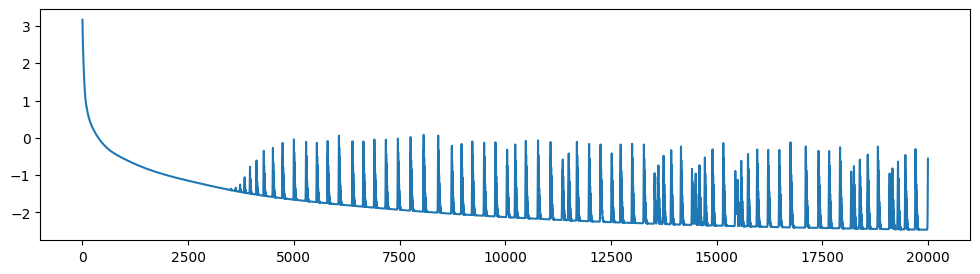

In [179]:
fig, ax = plt.subplots(1, 1, figsize=(12, 3))
ax.plot(jnp.log10(loss_trace))

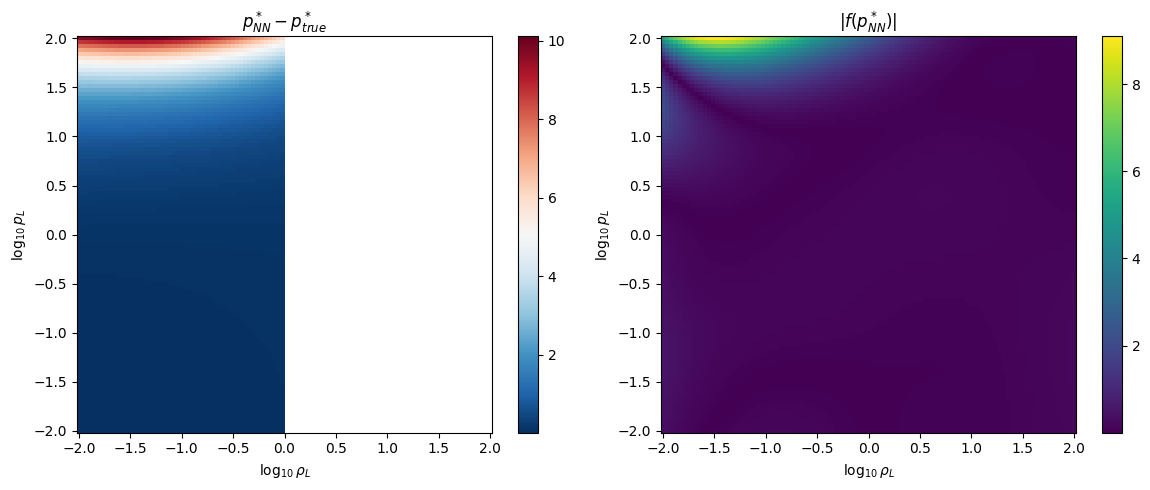

In [ ]:
# Fix right-state and velocity to mid-range values (in log space)
logrhoR_fix = 0.0  # mid of [-2, 2]
logpR_fix   = 0.0
uRL_fix     = 0.0  # mid of [-1, 1]

N = 100
logrhoL_vals = jnp.linspace(-2, 2, N)
logpL_vals   = jnp.linspace(-2, 2, N)
logrhoL_grid, logpL_grid = jnp.meshgrid(logrhoL_vals, logpL_vals, indexing='ij')

# Build (N*N, 5) input array
gas_states_log = jnp.stack([
    logrhoL_grid.ravel(),
    logpL_grid.ravel(),
    jnp.full(N*N, logrhoR_fix),
    jnp.full(N*N, logpR_fix),
    jnp.full(N*N, uRL_fix),
], axis=-1)

# NN predictions
logpstar_nn = forward(params, gas_states_log)            # (N*N,)
pstar_nn = 10.**logpstar_nn

# True solutions
logpstar_true = jax.vmap(find_pstar)(gas_states_log)[0]     # (N*N,)  — adjust call if needed
pstar_true = 10.**logpstar_true

# Residuals
gas_states = jnp.concatenate([10.**(gas_states_log[:, :4]), gas_states_log[:, 4:5]], axis=-1)
f_nn = jax.vmap(fstar)(pstar_nn, gas_states)

# Reshape for plotting
err  = (pstar_nn/pstar_true).reshape(N, N)
absf = jnp.abs(f_nn).reshape(N, N)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

c1 = ax1.pcolormesh(logrhoL_vals, logpL_vals, err.T, shading='auto', cmap='RdBu_r')
ax1.set_xlabel(r'$\log_{10}\rho_L$')
ax1.set_ylabel(r'$\log_{10}p_L$')
ax1.set_title(r'$p^*_{NN}/p^*_{true}$')
fig.colorbar(c1, ax=ax1)

c2 = ax2.pcolormesh(logrhoL_vals, logpL_vals, absf.T, shading='auto', cmap='viridis')
ax2.set_xlabel(r'$\log_{10}\rho_L$')
ax2.set_ylabel(r'$\log_{10}p_L$')
ax2.set_title(r'$|f(p^*_{NN})|$')
fig.colorbar(c2, ax=ax2)

plt.tight_layout()
plt.show()